# Library download

In [3]:
import json
import umap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set(style="whitegrid")

import pandas as pd
from pathlib import Path

In [21]:

# df['call_id']
# df['role']
# gen['target_sex']
# gen['operator_sex']

df = pd.read_csv("/home/user/papkamusik/action_folder/features.csv")
gen = pd.read_csv("/home/user/papkamusik/action_folder/male_female.csv")
# убираем последние 4 символа у всех значений
gen['audio_id'] = gen['audio_id'].str[:-4]
df['call_id'] = df['call_id'].astype(str)
gen['audio_id'] = gen['audio_id'].astype(str)

merged_df = pd.merge(df, gen, left_on='call_id', right_on='audio_id', how='left')

import numpy as np

# создаём новый столбец 'sex', который выбирает пол в зависимости от роли
merged_df['sex'] = np.where(
    merged_df['role'] == 'user',
    merged_df['target_sex'],   # если user → берём target
    merged_df['operator_sex']  # иначе (assistent) → берём operator
)

merged_df.drop(columns=['operator_sex','target_sex','audio_id'], inplace=True)

merged_df.to_csv("result_177.csv",index=False)

## Data download and preparaition

In [2]:
# ------------------------
# Настройки
# ------------------------
BASE_DIR = Path("/home/user/papkamusik/action_folder/")

# Если все данные в одном файле или уже объединены
full_data = "Yes"  # "Yes" или "No"

# Если муж/жен позиции в одном файле или отдельные
single_file = "Yes"  # "Yes" или "No"

# ------------------------
# Сбор всех CSV файлов features*.csv
# ------------------------
csv_files = list(BASE_DIR.rglob("features*.csv"))
if not csv_files:
    raise FileNotFoundError(f"Не найдено файлов features*.csv в {BASE_DIR}")

all_dfs = []

In [3]:
# ------------------------
# Вариант 1: все данные уже объединены
# ------------------------
if full_data == "Yes":
    print(f"Обработка всех файлов как единый набор данных ({len(csv_files)} файлов)")
    for csv_file in csv_files:
        print(f"Загрузка: {csv_file}")
        df = pd.read_csv(csv_file)

        # Приводим call_id к строковому типу
        if "call_id" in df.columns:
            df["call_id"] = df["call_id"].astype(str)

        all_dfs.append(df)

    final_df = pd.concat(all_dfs, ignore_index=True)

# ------------------------
# Вариант 2: данные разделены, нужен merge с male_female
# ------------------------
elif full_data == "No":
    male_female_path = BASE_DIR / "phone_gender_mapping.csv"
    if not male_female_path.exists():
        raise FileNotFoundError(f"Файл разметки пола не найден: {male_female_path}")

    male_female = pd.read_csv(male_female_path)
    male_female.columns = male_female.columns.str.strip()
    if "phone_hash" in male_female.columns:
        male_female["phone_hash"] = male_female["phone_hash"].astype(str)

    print(f"Обработка CSV файлов с merge разметки пола ({len(csv_files)} файлов)")
    for csv_file in csv_files:
        print(f"\nЗагрузка: {csv_file}")
        df = pd.read_csv(csv_file)
        df.columns = df.columns.str.strip()

        if "phone_hash" in df.columns:
            df["phone_hash"] = df["phone_hash"].astype(str)

        # Объединяем с разметкой пола
        merged = df.merge(male_female, on="phone_hash", how="left")

        print(f"Всего записей: {len(df)}")
        print(f"Совпадений по phone_hash: {merged['gender'].notna().sum()}")
        print(f"Пропущено после merge (NaN): {merged['gender'].isna().sum()}")

        all_dfs.append(merged)

    final_df = pd.concat(all_dfs, ignore_index=True)

Обработка всех файлов как единый набор данных (2 файлов)
Загрузка: /home/user/papkamusik/action_folder/features_with_gender.csv
Загрузка: /home/user/papkamusik/action_folder/features_177_updated.csv


In [4]:
# ------------------------
# Итог
# ------------------------
print("\nИтоговый размер объединённого DataFrame:")
print(final_df.shape)
print("Примеры данных:")
print(final_df.head())

# ------------------------
# При желании можно сохранить результат
# ------------------------
# final_df.to_csv(BASE_DIR / "final_features.csv", index=False)


Итоговый размер объединённого DataFrame:
(1016, 24)
Примеры данных:
     call_id  role  gender     f0_mean  f0_variance     f1_mean   f1_variance  \
0  0473d377e  user    Male  214.426112  1267.055560  508.615719  37667.771021   
1  a91927080  user    Male  129.411632   320.548333  474.638741  26923.718990   
2  4341000b3  user  Female  174.410142  1529.187739  472.718763  16654.973919   
3  c3952047f  user  Female  147.313963  1523.911108  418.718255  20391.670545   
4  88adfbc48  user    Male  108.705463  1597.584308  449.518310  17617.719131   

       f2_mean    f2_variance      f3_mean  ...  f2_slope  f2_range  f3_slope  \
0  1442.066097  142607.235449  2303.792815  ...       NaN       NaN       NaN   
1  1399.046115   68024.802197  2275.116439  ...       NaN       NaN       NaN   
2  1383.680478   79988.861572  2269.546500  ...       NaN       NaN       NaN   
3  1513.244984  141475.736334  2431.161653  ...       NaN       NaN       NaN   
4  1390.268894   67711.540840  2246.757

# Data vizualization

Characterization of each data column which are:
- Statistics (count, mean, std,	min, max, quantiles),
- Pearson's correlation,
- Distributions,
- Boxplots.

<class 'pandas.core.frame.DataFrame'>
Index: 158 entries, 0 to 158
Data columns (total 58 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   call_id         158 non-null    int64  
 1   role            158 non-null    object 
 2   f0_mean         158 non-null    float64
 3   f0_median       158 non-null    float64
 4   f0_variance     158 non-null    float64
 5   f0_std          158 non-null    float64
 6   f0_min          158 non-null    float64
 7   f0_max          158 non-null    float64
 8   f0_range        158 non-null    float64
 9   f0_skew         158 non-null    float64
 10  f0_kurtosis     158 non-null    float64
 11  f0_cv           158 non-null    float64
 12  f1_mean         158 non-null    float64
 13  f1_median       158 non-null    float64
 14  f1_variance     158 non-null    float64
 15  f1_std          158 non-null    float64
 16  f1_min          158 non-null    float64
 17  f1_max          158 non-null    float64


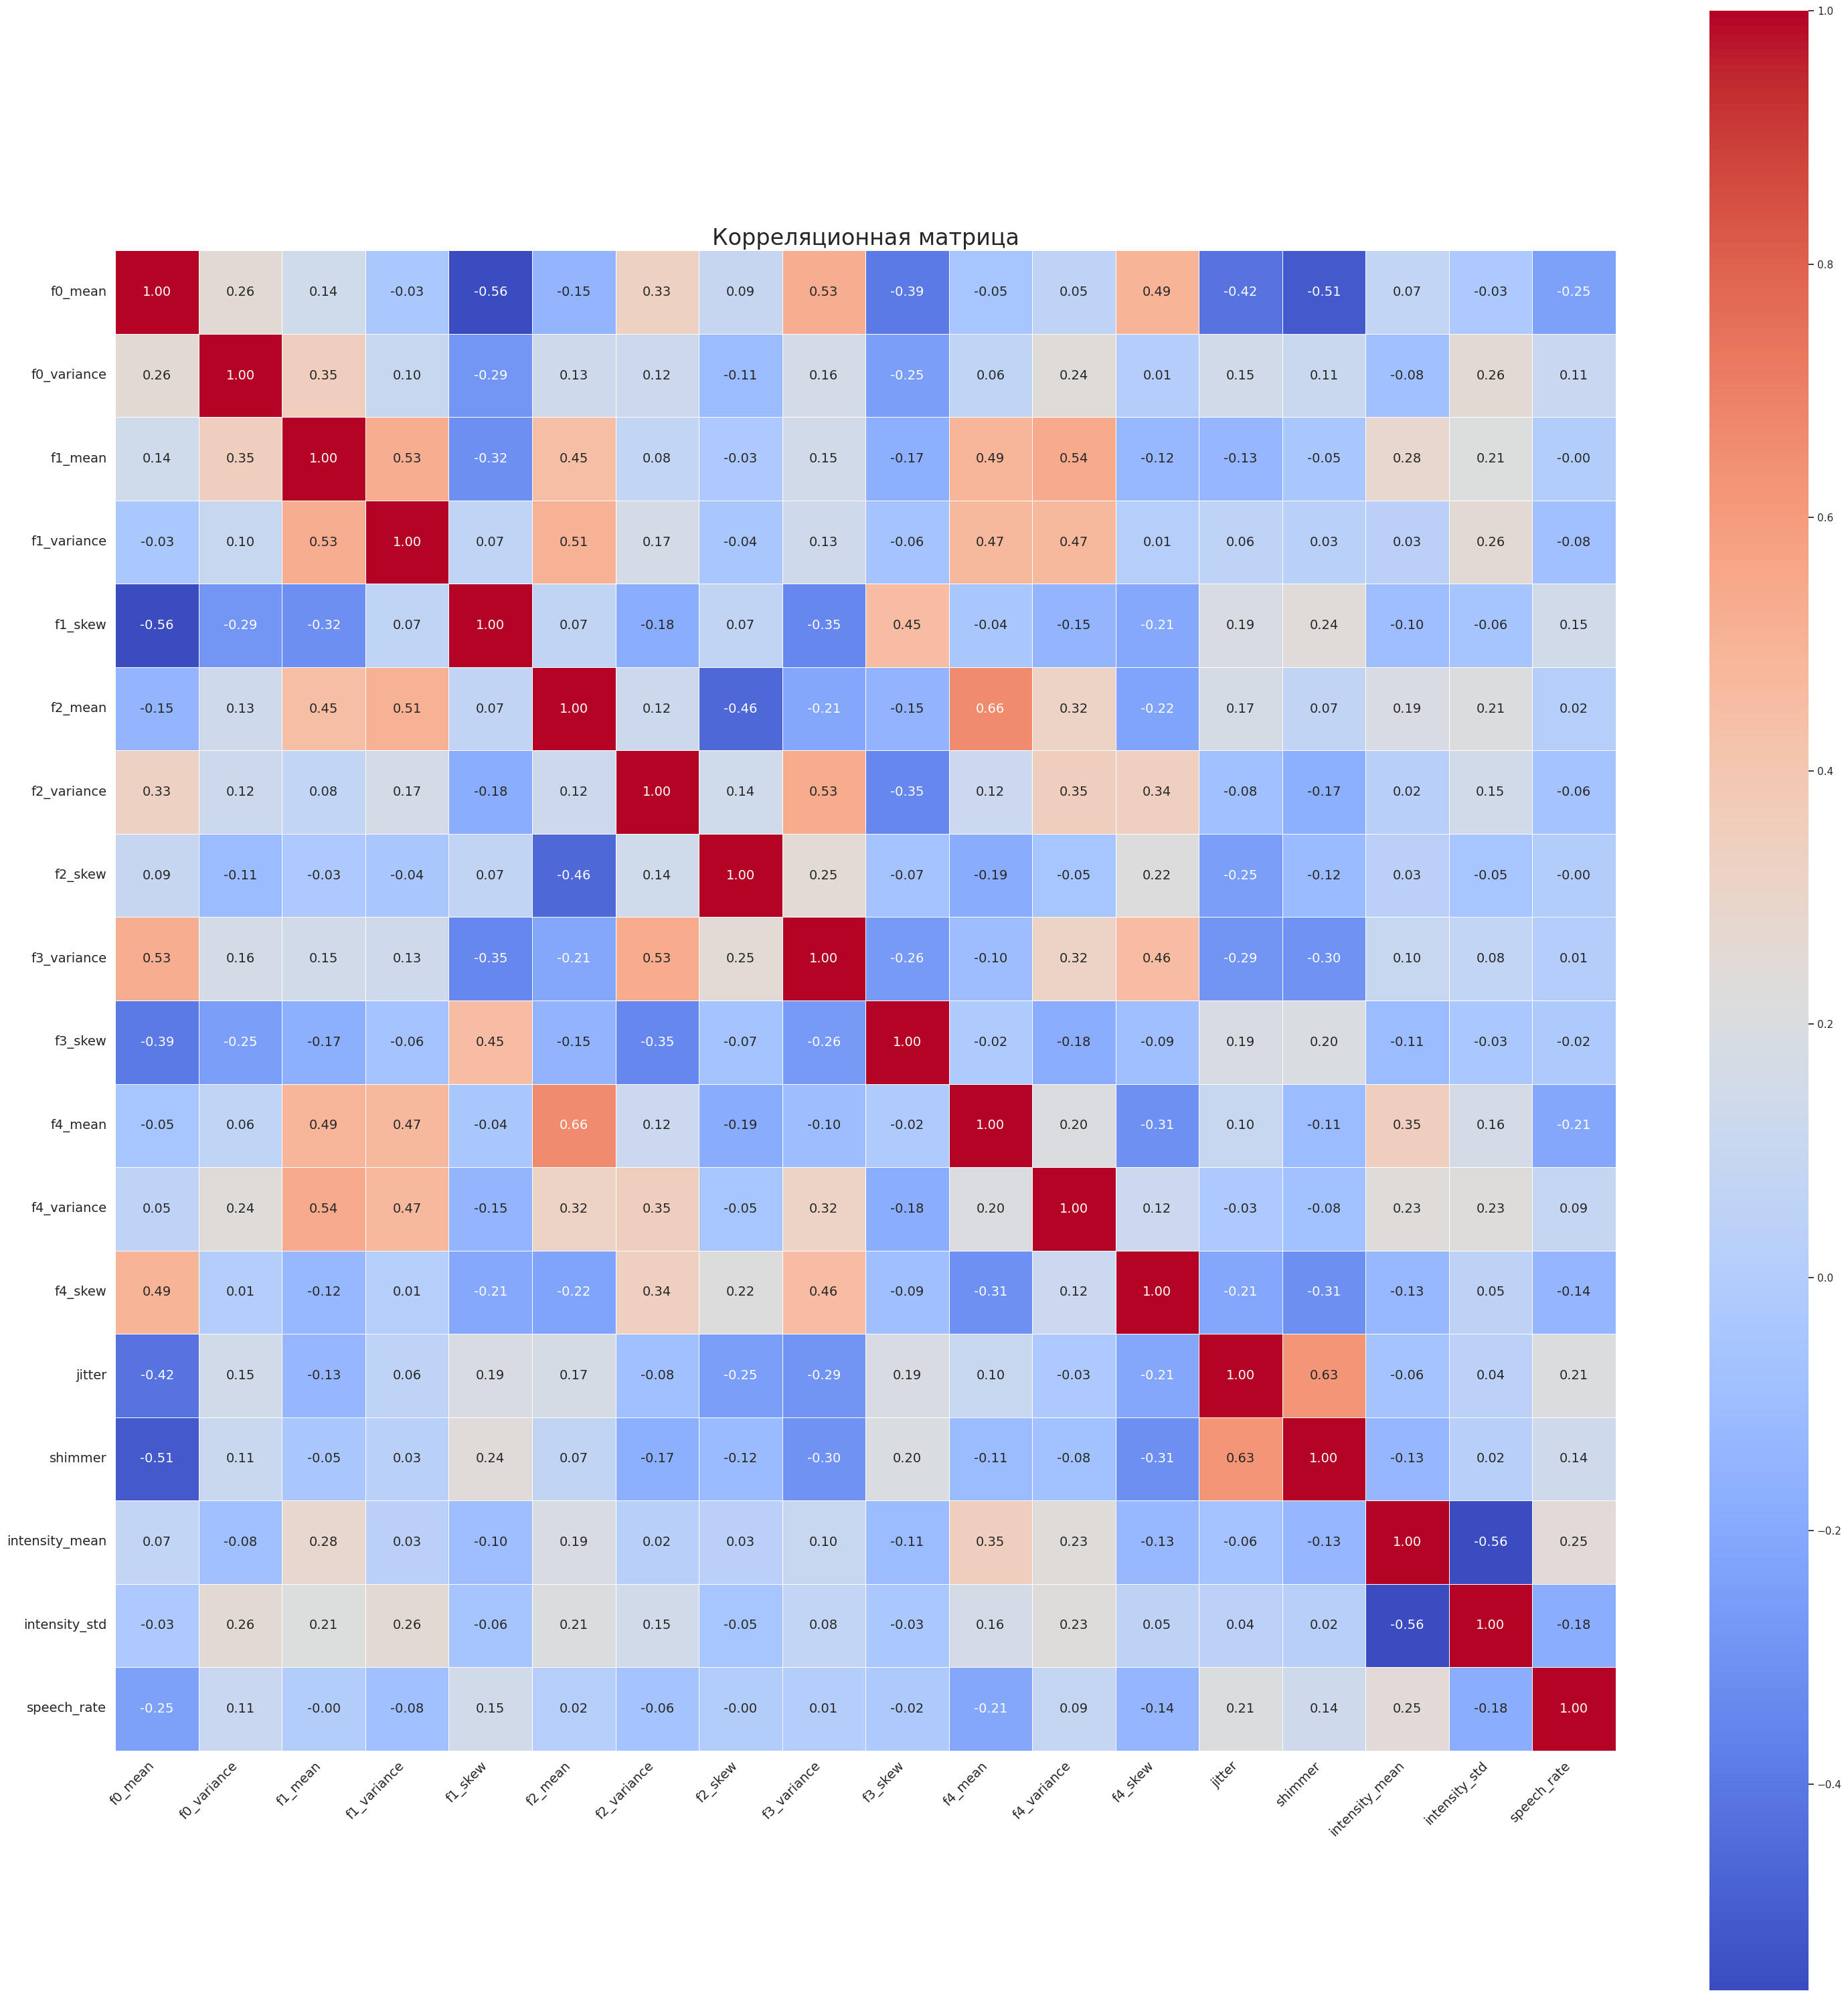

In [42]:
final_df = pd.read_csv("/home/user/papkamusik/action_folder/result_177.csv")
# Удаляем строки, где gender = "-"
final_df = final_df[final_df["sex"] != "-"].reset_index(drop=True)
# final_df = final_df[final_df["role"] != "assistant"].reset_index(drop=True)
final_df=final_df.dropna()

# final_df.sex.unique()
final_df.info()

import matplotlib.pyplot as plt
import seaborn as sns

# -------- выбираем числовые признаки --------

final_df.drop(columns=["call_id","f0_cv","f1_cv","f2_cv","f3_cv","f4_cv","f0_median","f1_median","f2_median","f3_median","f4_median",
                       "f0_range","f1_range","f2_range","f3_range","f4_range","f0_std","f1_std","f2_std","f3_std","f4_std",
                       "f0_min","f0_max","f1_min","f1_max","f2_min","f2_max","f3_min","f3_max","f4_min","f4_max","f1_kurtosis",
                       "f2_kurtosis","f3_kurtosis","f4_kurtosis","f0_kurtosis","f3_mean","f0_skew"], inplace=True)
numeric = final_df.select_dtypes(include=[np.number])
corr_matrix = numeric.corr()
# -------- корреляционная матрица --------
plt.figure(figsize=(30,30))  # увеличили размер

sns.set(font_scale=1)  # увеличили шрифт
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",              # округление чисел
    cmap="coolwarm",
    square=True,            # квадратные клетки
    linewidths=0.7,         # линии между клетками
    annot_kws={"size": 14}  # размер чисел внутри
)

plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(rotation=0, fontsize=14)

plt.title("Корреляционная матрица", fontsize=24)
plt.tight_layout()
plt.show()


# убираем дубликаты и диагональ
upper = corr_matrix.where(~np.tril(np.ones(corr_matrix.shape), k=0).astype(bool))

# выбираем пары с корреляцией > 0.7
high_corr = [(col1, col2, upper.loc[col1, col2]) 
             for col1 in upper.columns 
             for col2 in upper.columns 
             if pd.notnull(upper.loc[col1, col2]) and upper.loc[col1, col2] > 0.7]

# выводим
for col1, col2, val in high_corr:
    print(f"{col1} ↔ {col2}: {val:.2f}")

In [3]:
import pandas as pd
from pathlib import Path

# ------------------------
# Пути
# ------------------------
BASE_DIR = Path("/home/user/papkamusik/action_folder/")
server_csv = BASE_DIR / "features_with_gender.csv"
my_csv = BASE_DIR / "features_177_updated.csv"

# ------------------------
# Загружаем данные
# ------------------------
server_df = pd.read_csv(server_csv)
my_df = pd.read_csv(my_csv)

# ------------------------
# Выбираем только нужные колонки из my_df и переименовываем sex -> gender
# ------------------------
columns_to_keep = [
    "role", "f0_mean", "f0_variance",
    "f1_mean", "f1_variance",
    "f2_mean", "f2_variance",
    "f3_mean", "f3_variance",
    "sex"
]
my_subset = my_df[columns_to_keep].copy()
my_subset = my_subset.rename(columns={"sex": "gender"})

# ------------------------
# Добавляем call_id
# Если у тебя нет call_id во втором файле, можно сгенерировать новый уникальный id
# Например, по индексу + префикс
my_subset["call_id"] = ["my_" + str(i) for i in my_subset.index]

# ------------------------
# Переставляем колонки, чтобы совпадали с server_df
# server_df: call_id,role,gender,f0_mean,f0_variance,f1_mean,f1_variance,f2_mean,f2_variance,f3_mean,f3_variance
my_subset = my_subset[["call_id", "role", "gender",
                       "f0_mean", "f0_variance",
                       "f1_mean", "f1_variance",
                       "f2_mean", "f2_variance",
                       "f3_mean", "f3_variance"]]

# ------------------------
# Добавляем строки в server_df
final_df = pd.concat([server_df, my_subset], ignore_index=True)

# Переводим все значения в нижний регистр
final_df["gender"] = final_df["gender"].str.lower()
# Удаляем строки, где gender = "-"
final_df = final_df[final_df["gender"] != "-"].reset_index(drop=True)
final_df = final_df[final_df["role"] != "assistant"].reset_index(drop=True)
final_df=final_df.dropna()

# ------------------------
# Проверка
print("Исходный размер server_df:", server_df.shape)
print("Размер после добавления my_df:", final_df.shape)
print(final_df.tail())




# ------------------------
# При желании сохранить
final_df.to_csv(BASE_DIR / "features_with_gender_expanded.csv", index=False)

# -------- выбираем числовые признаки --------
numeric = final_df.select_dtypes(include=[np.number])

Исходный размер server_df: (839, 11)
Размер после добавления my_df: (511, 11)
    call_id  role  gender     f0_mean  f0_variance     f1_mean   f1_variance  \
543   my_89  user  female  239.507636  2082.188855  464.763081  37586.639956   
544   my_90  user  female  109.259401  1302.016883  452.349388  18664.624949   
545   my_91  user  female  191.488198   126.142453  413.146876  15567.687213   
546   my_92  user  female  167.884095  1042.677259  480.785802  28722.636457   
547   my_93  user  female  201.393082  1993.042788  549.450669  38251.539725   

         f2_mean    f2_variance      f3_mean    f3_variance  
543  1274.539114  129677.560653  2250.300426   31841.203734  
544  1340.904704   49648.600423  2218.088646   58238.879666  
545  1224.782948  148287.592779  2125.788559   65649.135410  
546  1367.557440  243951.474476  2341.069219  178560.589728  
547  1522.909912  218371.659175  2463.771153  108290.832859  


## Statistics

In [5]:
stats = numeric.describe().T

print("\nСтатистика признаков:")
display(stats)


Статистика признаков:


,count,mean,std,min,25%,50%,75%,max
f0_mean,511.0,176.199225,39.730380,89.417796,138.926018,189.096656,208.458172,250.665495
f0_variance,511.0,1354.881271,693.493146,0.197818,932.789625,1274.789071,1630.707260,5417.324982
f1_mean,511.0,482.659753,56.238899,323.619201,446.073863,476.438183,508.587168,742.564739
f1_variance,511.0,28004.616905,15701.330910,100.669195,18311.340822,24818.686372,33226.212546,160227.200905
f2_mean,511.0,1404.579855,120.851701,1036.253780,1328.001367,1403.962743,1482.166998,1877.531675
f2_variance,511.0,120659.745372,40535.145435,2925.243868,93055.438708,117053.315655,141886.418286,312836.848041
f3_mean,511.0,2304.040254,107.763561,1947.465278,2234.164422,2299.295079,2372.066516,2784.411711
f3_variance,511.0,93221.103544,34358.992634,24827.772907,67896.736726,89827.501935,114213.700884,234294.460888


# Correlation

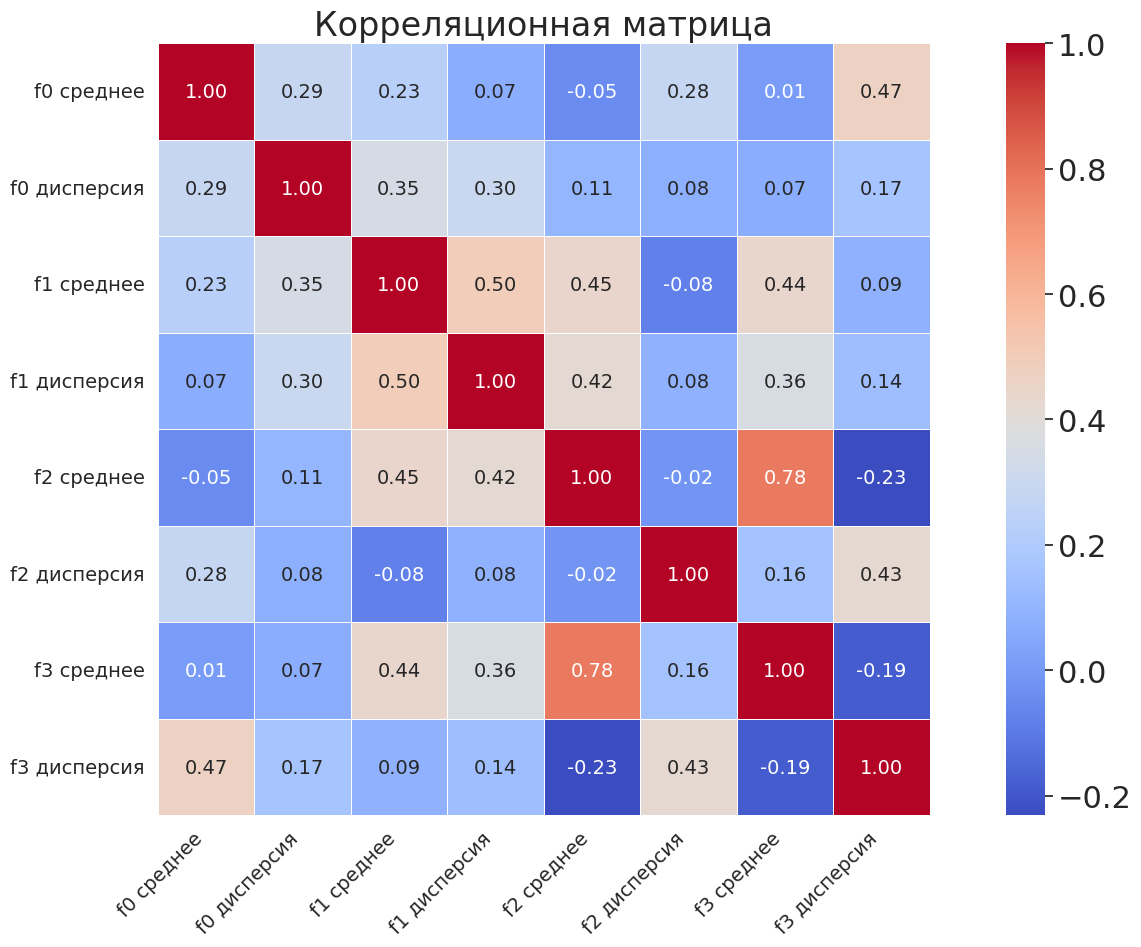

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Словарь для переименования столбцов
rename_dict = {
    "f0_mean": "f0 среднее",
    "f0_variance": "f0 дисперсия",
    "f1_mean": "f1 среднее",
    "f1_variance": "f1 дисперсия",
    "f2_mean": "f2 среднее",
    "f2_variance": "f2 дисперсия",
    "f3_mean": "f3 среднее",
    "f3_variance": "f3 дисперсия"
}

numeric_rus = numeric.rename(columns=rename_dict)

# -------- корреляционная матрица --------
plt.figure(figsize=(16,10))  # увеличили размер

sns.set(font_scale=2)  # увеличили шрифт
sns.heatmap(
    numeric_rus.corr(),
    annot=True,
    fmt=".2f",              # округление чисел
    cmap="coolwarm",
    square=True,            # квадратные клетки
    linewidths=0.7,         # линии между клетками
    annot_kws={"size": 14}  # размер чисел внутри
)

plt.xticks(rotation=45, ha="right", fontsize=14)
plt.yticks(rotation=0, fontsize=14)

plt.title("Корреляционная матрица", fontsize=24)
plt.tight_layout()
plt.show()

# Distribution

In [ ]:
# -------- распределения --------
for col in numeric.columns:
    plt.figure(figsize=(6,3))
    sns.histplot(numeric[col], kde=True, bins=30)
    plt.title(f"Распределение величины {col}")
    plt.show()

# Boxplot

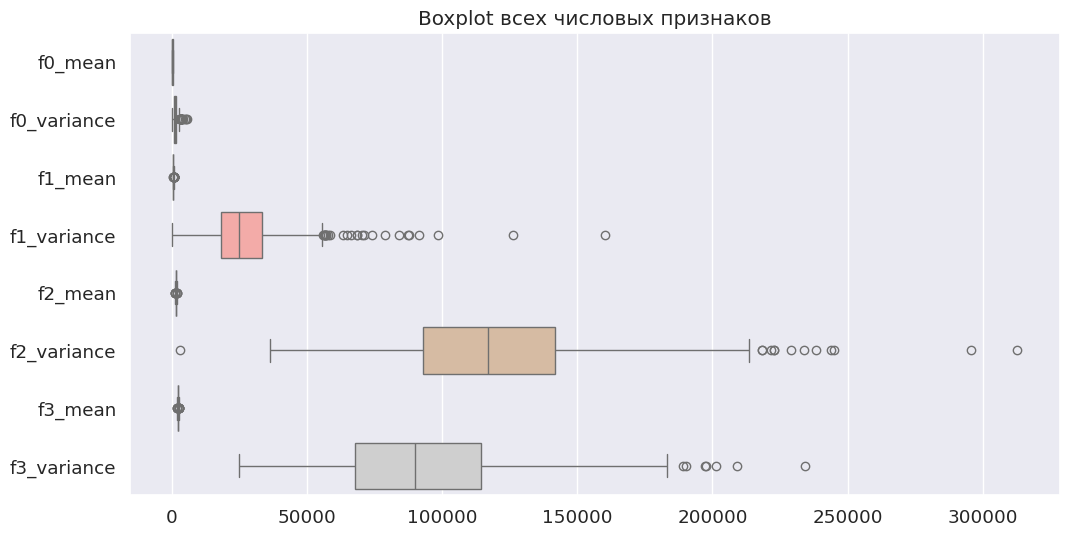

In [7]:
# -------- boxplot --------
plt.figure(figsize=(12,6))
sns.boxplot(data=numeric, orient='h', palette='pastel')
plt.title("Boxplot всех числовых признаков")
plt.show()

In [20]:
final_df.info()
final_df["gender"].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   call_id      998 non-null    object 
 1   role         998 non-null    object 
 2   gender       928 non-null    object 
 3   f0_mean      998 non-null    float64
 4   f0_variance  998 non-null    float64
 5   f1_mean      998 non-null    float64
 6   f1_variance  998 non-null    float64
 7   f2_mean      998 non-null    float64
 8   f2_variance  998 non-null    float64
 9   f3_mean      998 non-null    float64
 10  f3_variance  998 non-null    float64
dtypes: float64(8), object(3)
memory usage: 85.9+ KB


array(['male', 'female', nan], dtype=object)